<small>
Copyright (c) 2017 Andrew Glassner

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.
</small>



# Deep Learning From Basics to Practice
## by Andrew Glassner, https://dlbasics.com, http://glassner.com
------
## Chapter 23: Keras
### Notebook 6: MNIST training history

In [3]:
# Правильные импорты для современных версий TensorFlow/Keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical  # Исправленный импорт
from tensorflow.keras.metrics import F1Score
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import backend as keras_backend
keras_backend.set_image_data_format('channels_last')


In [ ]:
# Make a File_Helper for saving and loading files.

# save_files = True

# import os, sys, inspect
# current_dir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
# sys.path.insert(0, os.path.dirname(current_dir)) # path to parent dir
# from DLBasics_Utilities import File_Helper
# file_helper = File_Helper(save_files)

In [6]:
# Train our 2-layer MNIST classifier for 100 epochs.
random_seed = 42

# load MNIST data and save sizes
(X_train, y_train), (X_test, y_test) = mnist.load_data()
image_height = X_train.shape[1]
image_width = X_train.shape[2]
number_of_pixels = image_height * image_width

# convert to floating-point
X_train = keras_backend.cast_to_floatx(X_train)
X_test = keras_backend.cast_to_floatx(X_test)

# scale data to range [0, 1]
X_train /= 255.0
X_test /= 255.0

# save the original y_train and y_test
original_y_train = y_train
original_y_test = y_test

# replace label data with one-hot encoded versions
number_of_classes = int(1 + max(np.append(y_train, y_test)))
y_train = to_categorical(y_train, num_classes=number_of_classes)
y_test = to_categorical(y_test, num_classes=number_of_classes)

# reshape samples to 2D grid, one line per image
X_train = X_train.reshape([X_train.shape[0], number_of_pixels])
X_test = X_test.reshape([X_test.shape[0], number_of_pixels])

# make the model
model = Sequential([Input(shape=(number_of_pixels,)),
                    Dense(number_of_pixels, activation='relu'),
                    Dense(number_of_classes, activation='softmax')]
)
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy', 'precision', 'recall', F1Score(average='macro', threshold=0.5)]
)

np.random.seed(random_seed)

# call fit() to train the model, and save the history
one_hidden_layer_history = model.fit(X_train, y_train,
                                     validation_data=(X_test, y_test),
                                     epochs=100,
                                     batch_size=256,
                                     verbose=2
)

Epoch 1/100
235/235 - 7s - 31ms/step - accuracy: 0.9178 - f1_score: 0.9121 - loss: 0.2992 - precision: 0.9507 - recall: 0.8788 - val_accuracy: 0.9575 - val_f1_score: 0.9579 - val_loss: 0.1486 - val_precision: 0.9677 - val_recall: 0.9493
Epoch 2/100
235/235 - 5s - 20ms/step - accuracy: 0.9648 - f1_score: 0.9649 - loss: 0.1220 - precision: 0.9727 - recall: 0.9579 - val_accuracy: 0.9698 - val_f1_score: 0.9699 - val_loss: 0.0997 - val_precision: 0.9755 - val_recall: 0.9648
Epoch 3/100
235/235 - 6s - 23ms/step - accuracy: 0.9776 - f1_score: 0.9779 - loss: 0.0776 - precision: 0.9822 - recall: 0.9738 - val_accuracy: 0.9757 - val_f1_score: 0.9755 - val_loss: 0.0775 - val_precision: 0.9797 - val_recall: 0.9716
Epoch 4/100
235/235 - 4s - 19ms/step - accuracy: 0.9836 - f1_score: 0.9838 - loss: 0.0563 - precision: 0.9866 - recall: 0.9811 - val_accuracy: 0.9756 - val_f1_score: 0.9758 - val_loss: 0.0788 - val_precision: 0.9792 - val_recall: 0.9729
Epoch 5/100
235/235 - 5s - 20ms/step - accuracy: 0.9

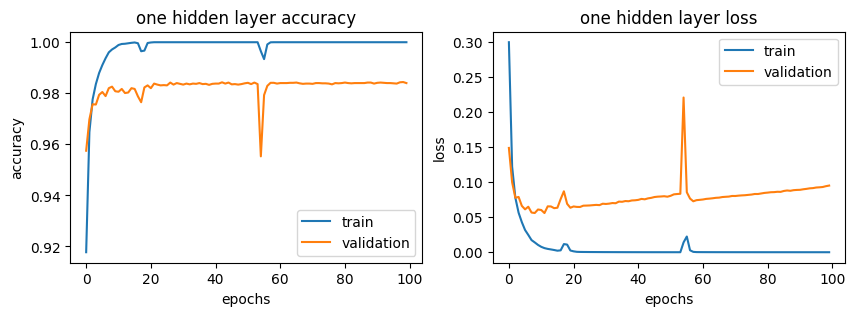

In [11]:
history = one_hidden_layer_history  # a copy with a shorter name
xs = range(len(history.history['accuracy']))

plt.figure(figsize=(10,3))
plt.subplot(1, 2, 1)
plt.plot(xs, history.history['accuracy'], label='train')
plt.plot(xs, history.history['val_accuracy'], label='validation')
plt.legend(loc='lower right')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('one hidden layer accuracy')

plt.subplot(1, 2, 2)
plt.plot(xs, history.history['loss'], label='train')
plt.plot(xs, history.history['val_loss'], label='validation')
plt.legend(loc='upper right')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('one hidden layer loss')

# file_helper.save_figure('one-hidden-layer-acc-loss')
plt.show()

In [8]:
# What's inside the history?
dir(one_hidden_layer_history)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_api_export_path',
 '_api_export_symbol_id',
 '_model',
 'epoch',
 'history',
 'model',
 'on_batch_begin',
 'on_batch_end',
 'on_epoch_begin',
 'on_epoch_end',
 'on_predict_batch_begin',
 'on_predict_batch_end',
 'on_predict_begin',
 'on_predict_end',
 'on_test_batch_begin',
 'on_test_batch_end',
 'on_test_begin',
 'on_test_end',
 'on_train_batch_begin',
 'on_train_batch_end',
 'on_train_begin',
 'on_train_end',
 'params',
 'set_model',
 'set_params']

In [9]:
# What's inside the 'history' field?
dir(one_hidden_layer_history.history)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'items',
 'keys',
 'pop',
 'popitem',
 'setdefault',
 'update',
 'values']